# Individual EDA and Main Dataset Builder

This notebook builds planning-area demand features from public transport footfall and enriches them with income and demographic context for downstream clustering.


## Workflow Overview

This notebook is organized into five steps:
1. Load the transport and geospatial source datasets.
2. Clean and geocode bus and train footfall records.
3. Map transport nodes to planning areas and derive footfall features.
4. Add income and demographic features at the planning-area level.
5. Prepare the final feature tables used for clustering.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path


In [2]:
# Load transport demand data
bus = pd.read_csv(Path('../dataset/LTA Footfall Traffic Datasets/transport_node_bus_202602.csv')).copy()
train = pd.read_csv(Path('../dataset/LTA Footfall Traffic Datasets/transport_node_train_202602.csv')).copy()

# Load geospatial reference data
import geopandas as gpd

bus_stops = gpd.read_file(Path('../dataset/Subzone and Locations Datasets/LTABusStop.geojson'))
mrt_exits = gpd.read_file(Path('../dataset/Subzone and Locations Datasets/LTAMRTStationExit.geojson'))
planning_areas = gpd.read_file(Path('../dataset/Subzone and Locations Datasets/SubzoneBoundary.geojson'))


## Bus Footfall Preparation

The bus workflow checks the raw file structure, removes incomplete records, standardizes join keys and attaches each bus stop to a geometry for later spatial joins.


In [3]:
display("Bus data preview")
display(bus.head())

bus_overview = pd.DataFrame(
    {
        "Metric": ["Rows", "Columns", "Duplicate rows"],
        "Value": [bus.shape[0], bus.shape[1], bus.duplicated().sum()]
    }
)

display("Bus dataset overview")
display(bus_overview)

bus_schema = pd.DataFrame(
    {
        "column": bus.columns,
        "dtype": bus.dtypes.astype(str).values,
        "non_null": bus.notna().sum().values,
        "missing": bus.isnull().sum().values,
        "unique": bus.nunique().values
    }
)

display("Column-level summary")
display(bus_schema)

display("Summary statistics for numerical columns")
display(bus.describe().T)


'Bus data preview'

,YEAR_MONTH,DAY_TYPE,TIME_PER_HOUR,PT_TYPE,PT_CODE,TOTAL_TAP_IN_VOLUME,TOTAL_TAP_OUT_VOLUME
0,2026-02,WEEKENDS/HOLIDAY,19.0,BUS,74941,241,618
1,2026-02,WEEKDAY,14.0,BUS,55381,87,85
2,2026-02,WEEKENDS/HOLIDAY,11.0,BUS,58429,9,89
3,2026-02,WEEKDAY,0.0,BUS,6161,23,60
4,2026-02,WEEKDAY,6.0,BUS,63161,26,98


'Bus dataset overview'

,Metric,Value
0,Rows,203124
1,Columns,7
2,Duplicate rows,0


'Column-level summary'

,column,dtype,non_null,missing,unique
0,YEAR_MONTH,str,203124,0,1
1,DAY_TYPE,str,203124,0,2
2,TIME_PER_HOUR,float64,203121,3,24
3,PT_TYPE,str,203124,0,1
4,PT_CODE,int64,203124,0,5196
5,TOTAL_TAP_IN_VOLUME,int64,203124,0,6544
6,TOTAL_TAP_OUT_VOLUME,int64,203124,0,6524


'Summary statistics for numerical columns'

,count,mean,std,min,25%,50%,75%,max
TIME_PER_HOUR,203121.0,13.258659,6.165798,0.0,9.0,13.0,18.0,23.0
PT_CODE,203124.0,49167.739819,25257.200282,1012.0,25621.0,50211.0,67181.0,99189.0
TOTAL_TAP_IN_VOLUME,203124.0,524.989366,1726.242158,0.0,31.0,151.0,486.0,126954.0
TOTAL_TAP_OUT_VOLUME,203124.0,524.989396,1660.152310,0.0,33.0,160.0,489.0,99581.0


In [4]:
# Review and remove incomplete bus records
bus_missing_rows = bus[bus.isnull().any(axis=1)]
display("Bus rows with missing values")
display(bus_missing_rows)

bus = bus.dropna()

# Standardize join keys before matching footfall data to stop geometry
bus_dtype_before = pd.DataFrame(
    {
        "field": ["bus.PT_CODE", "bus_stops.BUS_STOP_NUM"],
        "dtype_before": [str(bus["PT_CODE"].dtype), str(bus_stops["BUS_STOP_NUM"].dtype)]
    }
)

bus["PT_CODE"] = bus["PT_CODE"].astype(str)
bus_stops["BUS_STOP_NUM"] = bus_stops["BUS_STOP_NUM"].astype(str)

bus_dtype_after = pd.DataFrame(
    {
        "field": ["bus.PT_CODE", "bus_stops.BUS_STOP_NUM"],
        "dtype_after": [str(bus["PT_CODE"].dtype), str(bus_stops["BUS_STOP_NUM"].dtype)]
    }
)

bus_key_dtype_check = bus_dtype_before.merge(bus_dtype_after, on="field")
display("Key alignment data types")
display(bus_key_dtype_check)

set_footfall = set(bus["PT_CODE"])
set_geo = set(bus_stops["BUS_STOP_NUM"])

bus_key_summary = pd.DataFrame(
    {
        "Metric": [
            "Footfall stop codes",
            "Geospatial stop codes",
            "Matched stop codes",
            "Footfall codes missing in geometry",
            "Geometry codes missing in footfall",
            "Match ratio"
        ],
        "Value": [
            len(set_footfall),
            len(set_geo),
            len(set_footfall & set_geo),
            len(set_footfall - set_geo),
            len(set_geo - set_footfall),
            len(set_footfall & set_geo) / len(set_footfall)
        ]
    }
)

display("Bus key matching summary")
display(bus_key_summary)


'Bus rows with missing values'

,YEAR_MONTH,DAY_TYPE,TIME_PER_HOUR,PT_TYPE,PT_CODE,TOTAL_TAP_IN_VOLUME,TOTAL_TAP_OUT_VOLUME
49773,2026-02,WEEKENDS/HOLIDAY,NaN,BUS,82009,0,1
57619,2026-02,WEEKDAY,NaN,BUS,84009,0,1
94940,2026-02,WEEKDAY,NaN,BUS,45009,0,1


'Key alignment data types'

,field,dtype_before,dtype_after
0,bus.PT_CODE,int64,str
1,bus_stops.BUS_STOP_NUM,str,str


'Bus key matching summary'

,Metric,Value
0,Footfall stop codes,5196.000000
1,Geospatial stop codes,5148.000000
2,Matched stop codes,4773.000000
3,Footfall codes missing in geometry,423.000000
4,Geometry codes missing in footfall,375.000000
5,Match ratio,0.918591


In [5]:
# Attach bus stop geometry to each bus footfall record
bus_with_location = bus.merge(
    bus_stops[["BUS_STOP_NUM", "geometry"]],
    left_on="PT_CODE",
    right_on="BUS_STOP_NUM",
    how="left"
)

bus_location_summary = pd.DataFrame(
    {
        "Metric": ["Rows before dropping missing geometry", "Missing geometry share"],
        "Value": [len(bus_with_location), bus_with_location["geometry"].isnull().mean()]
    }
)

display("Bus records with geometry")
display(bus_with_location.head())
display("Bus geocoding summary")
display(bus_location_summary)

bus_with_location = bus_with_location.dropna(subset=["geometry"])
bus_with_location = bus_with_location.drop(columns=["BUS_STOP_NUM"])

display("Missing values after bus geocoding cleanup")
display(bus_with_location.isnull().sum())


'Bus records with geometry'

,YEAR_MONTH,DAY_TYPE,TIME_PER_HOUR,PT_TYPE,PT_CODE,TOTAL_TAP_IN_VOLUME,TOTAL_TAP_OUT_VOLUME,BUS_STOP_NUM,geometry
0,2026-02,WEEKENDS/HOLIDAY,19.0,BUS,74941,241,618,NaN,None
1,2026-02,WEEKDAY,14.0,BUS,55381,87,85,55381,POINT (103.83594 1.38998)
2,2026-02,WEEKENDS/HOLIDAY,11.0,BUS,58429,9,89,58429,POINT (103.81899 1.45155)
3,2026-02,WEEKDAY,0.0,BUS,6161,23,60,NaN,None
4,2026-02,WEEKDAY,6.0,BUS,63161,26,98,63161,POINT (103.87527 1.35723)


'Bus geocoding summary'

,Metric,Value
0,Rows before dropping missing geometry,203801.000000
1,Missing geometry share,0.078601


'Missing values after bus geocoding cleanup'

YEAR_MONTH              0
DAY_TYPE                0
TIME_PER_HOUR           0
PT_TYPE                 0
PT_CODE                 0
TOTAL_TAP_IN_VOLUME     0
TOTAL_TAP_OUT_VOLUME    0
geometry                0
dtype: int64

## Train Footfall Preparation

The train workflow builds a station-code lookup, resolves unmatched station names, collapses station exits into one representative point per station and then joins those locations back to the train footfall table.


In [6]:
display("Train data preview")
display(train.head())

train_overview = pd.DataFrame(
    {
        "Metric": ["Rows", "Columns", "Duplicate rows"],
        "Value": [train.shape[0], train.shape[1], train.duplicated().sum()]
    }
)

display("Train dataset overview")
display(train_overview)

train_schema = pd.DataFrame(
    {
        "column": train.columns,
        "dtype": train.dtypes.astype(str).values,
        "non_null": train.notna().sum().values,
        "missing": train.isnull().sum().values,
        "unique": train.nunique().values
    }
)

display("Column-level summary")
display(train_schema)

display("Summary statistics for numerical columns")
display(train.describe().T)


'Train data preview'

,YEAR_MONTH,DAY_TYPE,TIME_PER_HOUR,PT_TYPE,PT_CODE,TOTAL_TAP_IN_VOLUME,TOTAL_TAP_OUT_VOLUME
0,2026-02,WEEKENDS/HOLIDAY,10,TRAIN,PW7,1882,1060
1,2026-02,WEEKDAY,14,TRAIN,CC19/DT9,6843,6418
2,2026-02,WEEKDAY,9,TRAIN,NS5,34020,12584
3,2026-02,WEEKENDS/HOLIDAY,23,TRAIN,NS5,1933,8400
4,2026-02,WEEKDAY,8,TRAIN,PW3,1299,777


'Train dataset overview'

,Metric,Value
0,Rows,7259
1,Columns,7
2,Duplicate rows,0


'Column-level summary'

,column,dtype,non_null,missing,unique
0,YEAR_MONTH,str,7259,0,1
1,DAY_TYPE,str,7259,0,2
2,TIME_PER_HOUR,int64,7259,0,20
3,PT_TYPE,str,7259,0,1
4,PT_CODE,str,7259,0,182
5,TOTAL_TAP_IN_VOLUME,int64,7259,0,5706
6,TOTAL_TAP_OUT_VOLUME,int64,7259,0,5740


'Summary statistics for numerical columns'

,count,mean,std,min,25%,50%,75%,max
TIME_PER_HOUR,7259.0,13.338476,6.116479,0.0,9.0,14.0,19.0,23.0
TOTAL_TAP_IN_VOLUME,7259.0,10706.266566,16893.783344,0.0,1569.5,4387.0,12661.0,300397.0
TOTAL_TAP_OUT_VOLUME,7259.0,10672.468109,16979.160884,0.0,1667.0,4416.0,12157.5,293545.0


### Build Station Reference

Train footfall is keyed by station code, while the exit geometry file is keyed by station name. This section creates a consistent name-to-code lookup before aggregating exits to a single station point.


In [7]:
display("MRT exit reference preview")
display(mrt_exits.head())

mrt_codes = pd.read_csv(Path('../dataset/Subzone and Locations Datasets/TrainStationCodes.csv'))
display("Train station code reference")
display(mrt_codes.head())

mrt_codes["STATION_NA"] = (
    mrt_codes["mrt_station_english"]
    .str.upper()
    .str.strip()
    + " "
    + mrt_codes["mrt_line_english"].str.upper().apply(
        lambda x: "LRT STATION" if x.endswith("LRT") else "MRT STATION"
    )
)

mrt_exits_with_codes = mrt_exits.merge(
    mrt_codes[["STATION_NA", "stn_code"]],
    on="STATION_NA",
    how="left"
)

display("Train exits after initial code mapping")
display(mrt_exits_with_codes.head())

train_match_summary = pd.DataFrame(
    {
        "Metric": ["Exit records", "Missing station code share after initial join"],
        "Value": [len(mrt_exits_with_codes), mrt_exits_with_codes["stn_code"].isnull().mean()]
    }
)

display("Initial train station-code matching summary")
display(train_match_summary)

display("Unmatched station names after initial join")
display(mrt_exits_with_codes[mrt_exits_with_codes["stn_code"].isnull()].drop_duplicates())


'MRT exit reference preview'

,OBJECTID,STATION_NA,EXIT_CODE,INC_CRC,FMEL_UPD_D,geometry
0,17885,BRIGHT HILL MRT STATION,Exit 1,CFB9350F44E8991A,20251202172807,POINT (103.83364 1.36404)
1,17886,BRIGHT HILL MRT STATION,Exit 2,F273E9D550B06062,20251202172807,POINT (103.83351 1.36328)
2,17887,BRIGHT HILL MRT STATION,Exit 4,BC4A442B12F99E85,20251202172807,POINT (103.83195 1.36316)
3,17888,BRIGHT HILL MRT STATION,Exit 3,2A45076ED986B275,20251202172807,POINT (103.83238 1.36218)
4,17889,UPPER THOMSON MRT STATION,Exit 2,3EA737829473A972,20251202172807,POINT (103.83183 1.35574)


'Train station code reference'

,stn_code,mrt_station_english,mrt_station_chinese,mrt_line_english,mrt_line_chinese
0,NS1,Jurong East,裕廊东,North-South Line,南北线
1,NS2,Bukit Batok,武吉巴督,North-South Line,南北线
2,NS3,Bukit Gombak,武吉甘柏,North-South Line,南北线
3,NS4,Choa Chu Kang,蔡厝港,North-South Line,南北线
4,NS5,Yew Tee,油池,North-South Line,南北线


'Train exits after initial code mapping'

,OBJECTID,STATION_NA,EXIT_CODE,INC_CRC,FMEL_UPD_D,geometry,stn_code
0,17885,BRIGHT HILL MRT STATION,Exit 1,CFB9350F44E8991A,20251202172807,POINT (103.83364 1.36404),TE7
1,17886,BRIGHT HILL MRT STATION,Exit 2,F273E9D550B06062,20251202172807,POINT (103.83351 1.36328),TE7
2,17887,BRIGHT HILL MRT STATION,Exit 4,BC4A442B12F99E85,20251202172807,POINT (103.83195 1.36316),TE7
3,17888,BRIGHT HILL MRT STATION,Exit 3,2A45076ED986B275,20251202172807,POINT (103.83238 1.36218),TE7
4,17889,UPPER THOMSON MRT STATION,Exit 2,3EA737829473A972,20251202172807,POINT (103.83183 1.35574),TE8


'Initial train station-code matching summary'

,Metric,Value
0,Exit records,758.000000
1,Missing station code share after initial join,0.013193


'Unmatched station names after initial join'

,OBJECTID,STATION_NA,EXIT_CODE,INC_CRC,FMEL_UPD_D,geometry,stn_code
156,18164,CC9,E,D98C24C34886C2A7,20251202172807,POINT (103.89323 1.31829),NaN
157,18165,CC9,F,C1F2BBD57BDE56E9,20251202172807,POINT (103.89261 1.31674),NaN
186,18194,DT18,E,876C55E36105A859,20251202172807,POINT (103.8475 1.2827),NaN
187,18195,DT4,2,DEBE61198CBF6328,20251202172807,POINT (103.76865 1.35483),NaN
188,18196,DT18,D,1DD9022663718F32,20251202172807,POINT (103.8481 1.2826),NaN
189,18197,DT4,1,BFFFA021E82FCF75,20251202172807,POINT (103.7687 1.35506),NaN
415,18038,MARINA SOUTH MRT STATION,Exit 1,20846F5C306F5CFE,20251202172807,POINT (103.8615 1.27357),NaN
416,18039,MARINA SOUTH MRT STATION,Exit 2,AC98AC5E6E4A2440,20251202172807,POINT (103.86178 1.27386),NaN
417,18040,MARINA SOUTH MRT STATION,Exit 3,0D8225B43A9DB12A,20251202172807,POINT (103.86289 1.27314),NaN
418,18041,MARINA SOUTH MRT STATION,Exit 4,465066CFAE562319,20251202172807,POINT (103.86267 1.27551),NaN


In [8]:
# Manually fix known station-name mismatches
mrt_exits_with_codes["STATION_NA"] = mrt_exits_with_codes["STATION_NA"].replace({
    "CC9": "PAYA LEBAR MRT STATION",
    "DT18": "TELOK AYER MRT STATION",
    "DT4": "HUME MRT STATION",
})

mrt_exits_with_codes.loc[
    mrt_exits_with_codes["STATION_NA"] == "PAYA LEBAR MRT STATION", "stn_code"
] = "CC9"

mrt_exits_with_codes.loc[
    mrt_exits_with_codes["STATION_NA"] == "TELOK AYER MRT STATION", "stn_code"
] = "DT18"

mrt_exits_with_codes.loc[
    mrt_exits_with_codes["STATION_NA"] == "HUME MRT STATION", "stn_code"
] = "DT4"

mrt_exits_with_codes.loc[
    mrt_exits_with_codes["STATION_NA"] == "MARINA SOUTH MRT STATION", "stn_code"
] = "TE21"

# Expand single-station codes to interchange codes where train footfall uses combined labels
interchange_list = []
for code in train["PT_CODE"].unique():
    if len(code) > 4:
        interchange_list.append(code)

replacement_map = {}
for combo in interchange_list:
    codes = combo.split("/")
    for code in codes:
        replacement_map[code] = combo

mrt_exits_with_codes["stn_code"] = mrt_exits_with_codes["stn_code"].replace(replacement_map)

mrt_exits_with_codes["lon"] = mrt_exits_with_codes.geometry.x
mrt_exits_with_codes["lat"] = mrt_exits_with_codes.geometry.y

mrt_station_geo = (
    mrt_exits_with_codes.groupby("stn_code", as_index=False)
    .agg(
        STATION_NA=("STATION_NA", "first"),
        lon=("lon", "mean"),
        lat=("lat", "mean")
    )
)

mrt_station_geo = gpd.GeoDataFrame(
    mrt_station_geo,
    geometry=gpd.points_from_xy(mrt_station_geo["lon"], mrt_station_geo["lat"]),
    crs=mrt_exits_with_codes.crs
)

display("Station-level train geometry")
display(mrt_station_geo.head(10))

display("Post-cleaning station code coverage")
display(pd.DataFrame({
    "Metric": ["Missing station code share", "Missing geometry share"],
    "Value": [mrt_exits_with_codes["stn_code"].isnull().mean(), mrt_exits_with_codes["geometry"].isnull().mean()]
}))


'Station-level train geometry'

,stn_code,STATION_NA,lon,lat,geometry
0,BP10,FAJAR LRT STATION,103.770676,1.384465,POINT (103.77068 1.38447)
1,BP11,SEGAR LRT STATION,103.769410,1.387812,POINT (103.76941 1.38781)
2,BP12,JELAPANG LRT STATION,103.764677,1.386833,POINT (103.76468 1.38683)
3,BP13,SENJA LRT STATION,103.762326,1.382875,POINT (103.76233 1.38288)
4,BP2,SOUTH VIEW LRT STATION,103.745101,1.380318,POINT (103.7451 1.38032)
5,BP3,KEAT HONG LRT STATION,103.749227,1.378465,POINT (103.74923 1.37846)
6,BP4,TECK WHYE LRT STATION,103.753826,1.376564,POINT (103.75383 1.37656)
7,BP5,PHOENIX LRT STATION,103.758252,1.378614,POINT (103.75825 1.37861)
8,BP6/DT1,BUKIT PANJANG MRT STATION,103.762143,1.378622,POINT (103.76214 1.37862)
9,BP7,PETIR LRT STATION,103.766793,1.377603,POINT (103.76679 1.3776)


'Post-cleaning station code coverage'

,Metric,Value
0,Missing station code share,0.0
1,Missing geometry share,0.0


In [9]:
# Join train footfall to station geometry
train_with_location = train.merge(
    mrt_station_geo[["stn_code", "geometry", "STATION_NA"]],
    left_on="PT_CODE",
    right_on="stn_code",
    how="left"
)

display("Train records with geometry")
display(train_with_location.head())

display("Train records missing geometry before manual patch")
display(train_with_location[train_with_location["geometry"].isnull()].drop_duplicates())

display("Reference lookup for missing station")
display(mrt_station_geo.loc[mrt_station_geo["stn_code"] == "NE18"])

from shapely.geometry import Point

# Manually assign geometry for NE18 based on MRT station reference
ne18_point = Point(103.911111, 1.415278)
train_with_location.loc[
    train_with_location["PT_CODE"] == "NE18", "geometry"
] = ne18_point

train_with_location = train_with_location.drop(columns=["stn_code", "STATION_NA"])

display("Train geocoding summary after manual patch")
display(pd.DataFrame({
    "Metric": ["Rows", "Missing geometry share"],
    "Value": [len(train_with_location), train_with_location["geometry"].isnull().mean()]
}))

display(train_with_location.head(10))


'Train records with geometry'

,YEAR_MONTH,DAY_TYPE,TIME_PER_HOUR,PT_TYPE,PT_CODE,TOTAL_TAP_IN_VOLUME,TOTAL_TAP_OUT_VOLUME,stn_code,geometry,STATION_NA
0,2026-02,WEEKENDS/HOLIDAY,10,TRAIN,PW7,1882,1060,PW7,POINT (103.89722 1.40513),SOO TECK LRT STATION
1,2026-02,WEEKDAY,14,TRAIN,CC19/DT9,6843,6418,CC19/DT9,POINT (103.81545 1.32261),BOTANIC GARDENS MRT STATION
2,2026-02,WEEKDAY,9,TRAIN,NS5,34020,12584,NS5,POINT (103.74727 1.3975),YEW TEE MRT STATION
3,2026-02,WEEKENDS/HOLIDAY,23,TRAIN,NS5,1933,8400,NS5,POINT (103.74727 1.3975),YEW TEE MRT STATION
4,2026-02,WEEKDAY,8,TRAIN,PW3,1299,777,PW3,POINT (103.90676 1.41679),PUNGGOL POINT LRT STATION


'Train records missing geometry before manual patch'

,YEAR_MONTH,DAY_TYPE,TIME_PER_HOUR,PT_TYPE,PT_CODE,TOTAL_TAP_IN_VOLUME,TOTAL_TAP_OUT_VOLUME,stn_code,geometry,STATION_NA
17,2026-02,WEEKDAY,6,TRAIN,NE18,11103,3499,NaN,None,NaN
144,2026-02,WEEKENDS/HOLIDAY,23,TRAIN,NE18,671,1702,NaN,None,NaN
659,2026-02,WEEKDAY,0,TRAIN,NE18,8,581,NaN,None,NaN
664,2026-02,WEEKDAY,20,TRAIN,NE18,13139,9640,NaN,None,NaN
956,2026-02,WEEKDAY,16,TRAIN,NE18,18559,10498,NaN,None,NaN
988,2026-02,WEEKDAY,14,TRAIN,NE18,10787,13294,NaN,None,NaN
1066,2026-02,WEEKENDS/HOLIDAY,13,TRAIN,NE18,6950,7244,NaN,None,NaN
1610,2026-02,WEEKENDS/HOLIDAY,14,TRAIN,NE18,6928,6511,NaN,None,NaN
1614,2026-02,WEEKENDS/HOLIDAY,10,TRAIN,NE18,5505,6097,NaN,None,NaN
1625,2026-02,WEEKDAY,13,TRAIN,NE18,12359,17305,NaN,None,NaN


'Reference lookup for missing station'

,stn_code,STATION_NA,lon,lat,geometry


'Train geocoding summary after manual patch'

,Metric,Value
0,Rows,7259.0
1,Missing geometry share,0.0


,YEAR_MONTH,DAY_TYPE,TIME_PER_HOUR,PT_TYPE,PT_CODE,TOTAL_TAP_IN_VOLUME,TOTAL_TAP_OUT_VOLUME,geometry
0,2026-02,WEEKENDS/HOLIDAY,10,TRAIN,PW7,1882,1060,POINT (103.89722 1.40513)
1,2026-02,WEEKDAY,14,TRAIN,CC19/DT9,6843,6418,POINT (103.81545 1.32261)
2,2026-02,WEEKDAY,9,TRAIN,NS5,34020,12584,POINT (103.74727 1.3975)
3,2026-02,WEEKENDS/HOLIDAY,23,TRAIN,NS5,1933,8400,POINT (103.74727 1.3975)
4,2026-02,WEEKDAY,8,TRAIN,PW3,1299,777,POINT (103.90676 1.41679)
5,2026-02,WEEKENDS/HOLIDAY,20,TRAIN,PW7,877,1930,POINT (103.89722 1.40513)
6,2026-02,WEEKENDS/HOLIDAY,16,TRAIN,TE24,1643,1982,POINT (103.88608 1.29796)
7,2026-02,WEEKENDS/HOLIDAY,17,TRAIN,EW1,17006,18790,POINT (103.94924 1.37286)
8,2026-02,WEEKDAY,5,TRAIN,EW32,1247,1152,POINT (103.63954 1.33003)
9,2026-02,WEEKENDS/HOLIDAY,18,TRAIN,TE4,4088,3777,POINT (103.81816 1.3981)


## Combine Modes and Map to Planning Areas

Once both transport modes have geometry, they can be stacked into a single node-level dataset and spatially joined to planning-area polygons.


In [10]:
footfall_with_location = pd.concat([train_with_location, bus_with_location])
display("Combined footfall records")
display(footfall_with_location.head())

display("Planning area boundary preview")
display(planning_areas.head())

footfall_with_location = gpd.GeoDataFrame(
    footfall_with_location,
    geometry="geometry",
    crs=planning_areas.crs
)

display(pd.DataFrame({
    "Metric": ["Footfall CRS", "Planning area CRS"],
    "Value": [str(footfall_with_location.crs), str(planning_areas.crs)]
}))

footfall_with_area = gpd.sjoin(
    footfall_with_location,
    planning_areas[["PLN_AREA_N", "geometry"]],
    how="left",
    predicate="within"
)

footfall_with_area = footfall_with_area.drop(columns=["geometry", "index_right"], errors="ignore")
footfall_with_area = footfall_with_area.rename(columns={"PLN_AREA_N": "PLANNING_AREA"})
footfall_with_area["TOTAL_VOLUME"] = (
    footfall_with_area["TOTAL_TAP_IN_VOLUME"] + footfall_with_area["TOTAL_TAP_OUT_VOLUME"]
)
footfall_with_area["NET_INFLOW"] = (
    footfall_with_area["TOTAL_TAP_OUT_VOLUME"] - footfall_with_area["TOTAL_TAP_IN_VOLUME"]
)

display("Footfall with planning area mapping")
display(footfall_with_area.head())

display("Spatial join summary")
display(pd.DataFrame({
    "Metric": ["Rows", "Mapped planning areas", "Missing planning area share"],
    "Value": [
        len(footfall_with_area),
        footfall_with_area["PLANNING_AREA"].nunique(),
        footfall_with_area["PLANNING_AREA"].isnull().mean()
    ]
}))


'Combined footfall records'

,YEAR_MONTH,DAY_TYPE,TIME_PER_HOUR,PT_TYPE,PT_CODE,TOTAL_TAP_IN_VOLUME,TOTAL_TAP_OUT_VOLUME,geometry
0,2026-02,WEEKENDS/HOLIDAY,10.0,TRAIN,PW7,1882,1060,POINT (103.89722 1.40513)
1,2026-02,WEEKDAY,14.0,TRAIN,CC19/DT9,6843,6418,POINT (103.81545 1.32261)
2,2026-02,WEEKDAY,9.0,TRAIN,NS5,34020,12584,POINT (103.74727 1.3975)
3,2026-02,WEEKENDS/HOLIDAY,23.0,TRAIN,NS5,1933,8400,POINT (103.74727 1.3975)
4,2026-02,WEEKDAY,8.0,TRAIN,PW3,1299,777,POINT (103.90676 1.41679)


'Planning area boundary preview'

,OBJECTID,SUBZONE_NO,SUBZONE_N,SUBZONE_C,CA_IND,PLN_AREA_N,PLN_AREA_C,REGION_N,REGION_C,INC_CRC,FMEL_UPD_D,SHAPE.AREA,SHAPE.LEN,geometry
0,676,12,DEPOT ROAD,BMSZ12,N,BUKIT MERAH,BM,CENTRAL REGION,CR,C22DED671DE2A940,20191223152313,442297.509556,4281.667289,"POLYGON ((103.81454 1.28239, 103.81427 1.28253..."
1,677,2,BUKIT MERAH,BMSZ02,N,BUKIT MERAH,BM,CENTRAL REGION,CR,085EF219A5A1AEAD,20191223152313,411722.830243,3074.963234,"POLYGON ((103.82209 1.28049, 103.82209 1.28057..."
2,678,3,CHINATOWN,OTSZ03,Y,OUTRAM,OT,CENTRAL REGION,CR,EF2B9A91AF49E025,20191223152313,587222.679344,4297.599898,"POLYGON ((103.84375 1.28508, 103.84363 1.28518..."
3,679,4,PHILLIP,DTSZ04,Y,DOWNTOWN CORE,DT,CENTRAL REGION,CR,615D4EDDEF809F8E,20191223152313,39437.935270,871.554888,"POLYGON ((103.84962 1.28412, 103.84963 1.28414..."
4,680,5,RAFFLES PLACE,DTSZ05,Y,DOWNTOWN CORE,DT,CENTRAL REGION,CR,72107B11807074F4,20191223152313,188767.489706,1872.752161,"POLYGON ((103.85253 1.28617, 103.85236 1.28651..."


,Metric,Value
0,Footfall CRS,EPSG:4326
1,Planning area CRS,EPSG:4326


'Footfall with planning area mapping'

,YEAR_MONTH,DAY_TYPE,TIME_PER_HOUR,PT_TYPE,PT_CODE,TOTAL_TAP_IN_VOLUME,TOTAL_TAP_OUT_VOLUME,PLANNING_AREA,TOTAL_VOLUME,NET_INFLOW
0,2026-02,WEEKENDS/HOLIDAY,10.0,TRAIN,PW7,1882,1060,PUNGGOL,2942,-822
1,2026-02,WEEKDAY,14.0,TRAIN,CC19/DT9,6843,6418,TANGLIN,13261,-425
2,2026-02,WEEKDAY,9.0,TRAIN,NS5,34020,12584,CHOA CHU KANG,46604,-21436
3,2026-02,WEEKENDS/HOLIDAY,23.0,TRAIN,NS5,1933,8400,CHOA CHU KANG,10333,6467
4,2026-02,WEEKDAY,8.0,TRAIN,PW3,1299,777,PUNGGOL,2076,-522


'Spatial join summary'

,Metric,Value
0,Rows,195041.000000
1,Mapped planning areas,50.000000
2,Missing planning area share,0.000661


### Footfall Measures

Two measures are used throughout the rest of the notebook:
- `TOTAL_VOLUME` captures total activity at a node as tap-ins plus tap-outs.
- `NET_INFLOW` compares tap-outs against tap-ins. Positive values are more destination-like, while negative values are more origin-like.


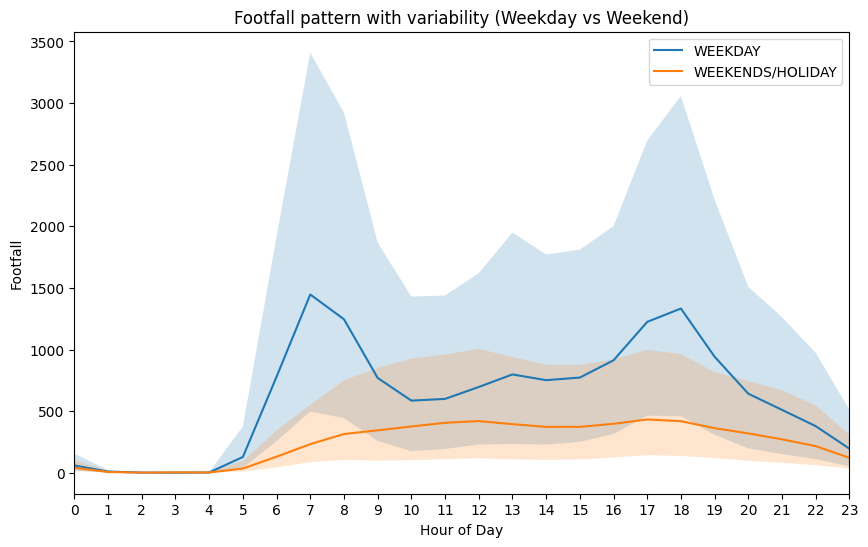

In [11]:
footfall_stats = (
    footfall_with_area.groupby(["DAY_TYPE", "TIME_PER_HOUR", "PT_CODE"])
    .agg(TOTAL_VOLUME=("TOTAL_VOLUME", "sum"))
    .reset_index()
)

footfall_stats = (
    footfall_stats.groupby(["DAY_TYPE", "TIME_PER_HOUR"])
    .agg(
        median=("TOTAL_VOLUME", "median"),
        p25=("TOTAL_VOLUME", lambda x: np.percentile(x, 25)),
        p75=("TOTAL_VOLUME", lambda x: np.percentile(x, 75))
    )
    .reset_index()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for day in footfall_stats["DAY_TYPE"].unique():
    subset = footfall_stats[footfall_stats["DAY_TYPE"] == day]
    plt.plot(subset["TIME_PER_HOUR"], subset["median"], label=day)
    plt.fill_between(subset["TIME_PER_HOUR"], subset["p25"], subset["p75"], alpha=0.2)

plt.xticks(range(24))
plt.xlim(0, 23)
plt.xlabel("Hour of Day")
plt.ylabel("Footfall")
plt.title("Footfall pattern with variability (Weekday vs Weekend)")
plt.legend()
plt.show()


### Footfall Pattern Interpretation

The weekday and weekend profiles show different demand rhythms:
- Weekdays have stronger commuter peaks in the morning and evening, with a smaller lunchtime increase.
- Weekends are flatter and build more gradually through midday and the afternoon.
- Weekend demand is generally lower overall, which suggests less commuter-driven traffic.

These patterns motivate the time bands used later for feature engineering:
- Weekday `morning`: 7 AM to 9 AM
- Weekday `lunch`: 11 AM to 2 PM
- Weekday `evening`: 4 PM to 8 PM
- Weekend `lunch`: 11 AM to 2 PM
- Weekend `afternoon`: after 2 PM to 6 PM


In [12]:
def get_time_band(row):
    hour = row["TIME_PER_HOUR"]
    day = row["DAY_TYPE"]

    day = day.strip().upper()

    if day == "WEEKDAY":
        if 7 <= hour <= 9:
            return "morning"
        elif 11 <= hour <= 14:
            return "lunch"
        elif 16 <= hour <= 20:
            return "evening"
        else:
            return "other"
    else:
        if 11 <= hour <= 14:
            return "lunch"
        elif 14 < hour <= 18:
            return "afternoon"
        else:
            return "other"

footfall_with_area["TIME_BAND"] = footfall_with_area.apply(get_time_band, axis=1)

display("Time band coverage summary")
display(pd.DataFrame({
    "Metric": ["Planning areas represented"],
    "Value": [footfall_with_area["PLANNING_AREA"].nunique()]
}))

display(footfall_with_area.head())


'Time band coverage summary'

,Metric,Value
0,Planning areas represented,50


,YEAR_MONTH,DAY_TYPE,TIME_PER_HOUR,PT_TYPE,PT_CODE,TOTAL_TAP_IN_VOLUME,TOTAL_TAP_OUT_VOLUME,PLANNING_AREA,TOTAL_VOLUME,NET_INFLOW,TIME_BAND
0,2026-02,WEEKENDS/HOLIDAY,10.0,TRAIN,PW7,1882,1060,PUNGGOL,2942,-822,other
1,2026-02,WEEKDAY,14.0,TRAIN,CC19/DT9,6843,6418,TANGLIN,13261,-425,lunch
2,2026-02,WEEKDAY,9.0,TRAIN,NS5,34020,12584,CHOA CHU KANG,46604,-21436,morning
3,2026-02,WEEKENDS/HOLIDAY,23.0,TRAIN,NS5,1933,8400,CHOA CHU KANG,10333,6467,other
4,2026-02,WEEKDAY,8.0,TRAIN,PW3,1299,777,PUNGGOL,2076,-522,morning


## Aggregate Planning-Area Features

This section rolls node-level footfall up to planning areas and keeps three views of demand: overall volume, weekday versus weekend volume and volume by time band.


In [13]:
area_base = (
    footfall_with_area.groupby("PLANNING_AREA", as_index=False)
    .agg(
        total_footfall=("TOTAL_VOLUME", "sum"),
        total_inflow=("NET_INFLOW", "sum")
    )
)

area_daytype = (
    footfall_with_area.groupby(["PLANNING_AREA", "DAY_TYPE"], as_index=False)
    .agg(total=("TOTAL_VOLUME", "sum"))
)

area_daytype_pivot = area_daytype.pivot(
    index="PLANNING_AREA",
    columns="DAY_TYPE",
    values="total"
).fillna(0).reset_index()

area_daytype_pivot.columns = [
    "PLANNING_AREA",
    "weekday_volume",
    "weekend_volume"
]

area_time = (
    footfall_with_area.groupby(["PLANNING_AREA", "TIME_BAND"], as_index=False)
    .agg(total=("TOTAL_VOLUME", "sum"))
)

area_time_pivot = area_time.pivot(
    index="PLANNING_AREA",
    columns="TIME_BAND",
    values="total"
).fillna(0).reset_index()

master_area_features = area_base.merge(
    area_daytype_pivot,
    on="PLANNING_AREA",
    how="left"
).merge(
    area_time_pivot,
    on="PLANNING_AREA",
    how="left"
)

display("Base planning-area feature table")
display(master_area_features.head())


'Base planning-area feature table'

,PLANNING_AREA,total_footfall,total_inflow,weekday_volume,weekend_volume,afternoon,evening,lunch,morning,other
0,ANG MO KIO,12643933,-55151,9188236,3455697,912723,3075086,2625614,2266392,3764118
1,BEDOK,17435585,100131,12241821,5193764,1406209,4168207,3620726,2940278,5300165
2,BISHAN,6582346,-200892,4724065,1858281,500037,1606145,1437977,1182105,1856082
3,BOON LAY,342658,34532,255329,87329,23326,93916,34464,91175,99777
4,BUKIT BATOK,9742955,-40587,6957018,2785937,754172,2407520,1975790,1648436,2957037


## Income Features

Household income is grouped into low-, mid- and high-income bands before being merged into the planning-area demand table.


In [14]:
income = pd.read_csv(Path('../dataset/Singstat Demographic and Income Datasets/ResidentHouseholdsbyPlanningAreaofResidenceandMonthlyHouseholdIncomefromWorkCensusOfPopulation2020.csv')).copy()

income = income[income["Number"] != "Total"]
income["Number"] = income["Number"].str.upper().str.strip()
income = income.rename(columns={"Number": "PLANNING_AREA"})

display("Income data preview")
display(income.head())

low_cols = [
    "Below_1_000", "1_000_1_999", "2_000_2_999", "3_000_3_999"
]

mid_cols = [
    "4_000_4_999", "5_000_5_999", "6_000_6_999",
    "7_000_7_999", "8_000_8_999", "9_000_9_999"
]

high_cols = [
    "10_000_10_999", "11_000_11_999", "12_000_12_999",
    "13_000_13_999", "14_000_14_999",
    "15_000_17_499", "17_500_19_999", "20_000andOver"
]

income["low_income"] = income[low_cols].sum(axis=1)
income["mid_income"] = income[mid_cols].sum(axis=1)
income["high_income"] = income[high_cols].sum(axis=1)

income_areas = income["PLANNING_AREA"].str.upper().str.strip()
area_areas = master_area_features["PLANNING_AREA"]
common = set(income_areas) & set(area_areas)

display("Income coverage check")
display(pd.DataFrame({
    "Metric": ["Income areas", "Planning areas in feature table", "Common areas"],
    "Value": [len(set(income_areas)), len(set(area_areas)), len(common)]
}))

master_area_features = master_area_features.merge(
    income[["PLANNING_AREA", "low_income", "mid_income", "high_income"]],
    on="PLANNING_AREA",
    how="left"
)

display(master_area_features.head())


'Income data preview'

,PLANNING_AREA,Total,NoEmployedPerson,Below_1_000,1_000_1_999,2_000_2_999,3_000_3_999,4_000_4_999,5_000_5_999,6_000_6_999,...,8_000_8_999,9_000_9_999,10_000_10_999,11_000_11_999,12_000_12_999,13_000_13_999,14_000_14_999,15_000_17_499,17_500_19_999,20_000andOver
1,ANG MO KIO,60220,11455,1563,4228,3572,4020,3381,3134,2943,...,2210,2386,1947,1795,1363,1425,1156,2661,1841,6466
2,BEDOK,97551,16818,2203,5278,5245,5521,4641,5102,3868,...,3455,3641,3291,2685,2620,2564,1838,4080,3349,17125
3,BISHAN,29445,4412,508,983,910,1252,996,1225,1307,...,1060,1014,903,983,900,854,805,1801,1589,6864
4,BUKIT BATOK,54297,5983,847,3328,3031,3136,3200,3206,2713,...,2813,2359,2003,2187,1504,1640,1475,2963,2037,7142
5,BUKIT MERAH,59700,12444,1899,4583,3478,3465,2339,2557,2173,...,1826,1787,2012,1748,1536,1337,1360,3129,2025,7748


'Income coverage check'

,Metric,Value
0,Income areas,31
1,Planning areas in feature table,50
2,Common areas,30


,PLANNING_AREA,total_footfall,total_inflow,weekday_volume,weekend_volume,afternoon,evening,lunch,morning,other,low_income,mid_income,high_income
0,ANG MO KIO,12643933,-55151,9188236,3455697,912723,3075086,2625614,2266392,3764118,13383.0,16726.0,18654.0
1,BEDOK,17435585,100131,12241821,5193764,1406209,4168207,3620726,2940278,5300165,18247.0,24936.0,37552.0
2,BISHAN,6582346,-200892,4724065,1858281,500037,1606145,1437977,1182105,1856082,3653.0,6680.0,14699.0
3,BOON LAY,342658,34532,255329,87329,23326,93916,34464,91175,99777,NaN,NaN,NaN
4,BUKIT BATOK,9742955,-40587,6957018,2785937,754172,2407520,1975790,1648436,2957037,10342.0,17022.0,20951.0


## Demographic Features

Population data is first cleaned at the subzone level, then rolled up to planning areas so that broad age-group counts can be added to the final area feature table.


In [15]:
demo = pd.read_csv(Path('../dataset/Singstat Demographic and Income Datasets/ResidentPopulationbyPlanningAreaSubzoneofResidenceAgeGroupandSexCensusofPopulation2020.csv')).copy()

demo = demo[demo["Number"] != "Total"]
demo["Number"] = demo["Number"].str.upper().str.strip()
demo = demo.rename(columns={"Number": "SUBZONE"})

cols_to_keep = ["SUBZONE"] + [col for col in demo.columns if col.startswith("Total_")]
demo = demo[cols_to_keep]

cols = demo.columns.difference(["SUBZONE"])
demo[cols] = demo[cols].apply(pd.to_numeric, errors="coerce")

for col in cols:
    if (demo[col].dropna() % 1 == 0).all():
        demo[col] = demo[col].astype("Int64")

# Create broad age groups at the subzone level
demo = demo.copy()
demo["children"] = demo["Total_0_4"] + demo["Total_5_9"] + demo["Total_10_14"]
demo["teens_youth"] = demo["Total_15_19"] + demo["Total_20_24"]
demo["young_adults"] = demo["Total_25_29"] + demo["Total_30_34"]
demo["mid_age_adults"] = (
    demo["Total_35_39"] + demo["Total_40_44"] + demo["Total_45_49"] + demo["Total_50_54"]
)
demo["older_adults"] = demo["Total_55_59"] + demo["Total_60_64"]
demo["seniors"] = (
    demo["Total_65_69"] + demo["Total_70_74"] + demo["Total_75_79"] +
    demo["Total_80_84"] + demo["Total_85_89"] + demo["Total_90andOver"]
)

age_cols = ["children", "teens_youth", "young_adults", "mid_age_adults", "older_adults", "seniors"]
for col in age_cols:
    demo[f"{col}_ratio"] = demo[col] / demo["Total_Total"]

lookup = planning_areas[["SUBZONE_N", "PLN_AREA_N"]].drop_duplicates()
lookup = lookup.rename(columns={"SUBZONE_N": "SUBZONE", "PLN_AREA_N": "PLANNING_AREA"})

demo["SUBZONE"] = demo["SUBZONE"].str.strip().str.upper()
lookup["SUBZONE"] = lookup["SUBZONE"].str.strip().str.upper()

demo_pa = demo.merge(lookup, on="SUBZONE", how="left")

display("Subzones without a planning area match")
display(demo_pa[demo_pa["PLANNING_AREA"].isna()].head(10))


'Subzones without a planning area match'

,SUBZONE,Total_Total,Total_0_4,Total_5_9,Total_10_14,Total_15_19,Total_20_24,Total_25_29,Total_30_34,Total_35_39,...,mid_age_adults,older_adults,seniors,children_ratio,teens_youth_ratio,young_adults_ratio,mid_age_adults_ratio,older_adults_ratio,seniors_ratio,PLANNING_AREA
0,ANG MO KIO - TOTAL,162280,5280,6100,7030,7600,8680,10320,10490,10420,...,46040,25510,35220,0.113446,0.10032,0.128235,0.283707,0.157197,0.217032,NaN
13,BEDOK - TOTAL,276990,9790,11490,12810,14080,16050,18870,18360,17730,...,78370,43810,53370,0.123073,0.108776,0.134409,0.282934,0.158165,0.192678,NaN
22,BISHAN - TOTAL,87320,2790,3720,4300,4630,5240,6930,5730,5090,...,23850,14090,16040,0.123798,0.113033,0.144984,0.273133,0.161361,0.183692,NaN
26,BOON LAY - TOTAL,40,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
31,BUKIT BATOK - TOTAL,158030,7920,6820,7690,8570,9800,12480,13630,10980,...,45220,24250,21670,0.141935,0.116244,0.165222,0.286148,0.153452,0.137126,NaN
41,BUKIT MERAH - TOTAL,151250,5970,6470,6670,6130,6640,8890,10540,10650,...,44860,21780,33310,0.126347,0.08443,0.128463,0.296595,0.144,0.220231,NaN
59,BUKIT PANJANG - TOTAL,138270,6250,7090,7310,8150,9290,10530,10460,10100,...,40050,21530,17610,0.149345,0.12613,0.151804,0.289651,0.15571,0.12736,NaN
67,BUKIT TIMAH - TOTAL,77860,3130,4900,4950,4850,4630,4570,4120,4800,...,23380,10260,13090,0.166709,0.121757,0.111611,0.300283,0.131775,0.168122,NaN
76,CENTRAL WATER CATCHMENT - TOTAL,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
78,CHANGI- TOTAL,1850,130,140,150,110,100,90,140,150,...,610,200,190,0.227027,0.113514,0.124324,0.32973,0.108108,0.102703,NaN


In [16]:
value_cols = [col for col in demo_pa.columns if col.startswith("Total_")]

demo_pa = (
    demo_pa.groupby("PLANNING_AREA", as_index=False)[value_cols]
    .sum(min_count=1)
)

demo_pa["children"] = demo_pa[["Total_0_4", "Total_5_9", "Total_10_14"]].sum(axis=1, min_count=1)
demo_pa["teens_youth"] = demo_pa[["Total_15_19", "Total_20_24"]].sum(axis=1, min_count=1)
demo_pa["young_adults"] = demo_pa[["Total_25_29", "Total_30_34"]].sum(axis=1, min_count=1)
demo_pa["mid_age_adults"] = demo_pa[["Total_35_39", "Total_40_44", "Total_45_49", "Total_50_54"]].sum(axis=1, min_count=1)
demo_pa["older_adults"] = demo_pa[["Total_55_59", "Total_60_64"]].sum(axis=1, min_count=1)
demo_pa["seniors"] = demo_pa[["Total_65_69", "Total_70_74", "Total_75_79", "Total_80_84", "Total_85_89", "Total_90andOver"]].sum(axis=1, min_count=1)

master_area_features = master_area_features.merge(
    demo_pa[["PLANNING_AREA", "children", "teens_youth", "young_adults", "mid_age_adults", "older_adults", "seniors"]],
    on="PLANNING_AREA",
    how="left"
)

display("Planning-area features after demographic merge")
display(master_area_features.head())


'Planning-area features after demographic merge'

,PLANNING_AREA,total_footfall,total_inflow,weekday_volume,weekend_volume,afternoon,evening,lunch,morning,other,low_income,mid_income,high_income,children,teens_youth,young_adults,mid_age_adults,older_adults,seniors
0,ANG MO KIO,12643933,-55151,9188236,3455697,912723,3075086,2625614,2266392,3764118,13383.0,16726.0,18654.0,18420,16280,20820,46030,25540,35210
1,BEDOK,17435585,100131,12241821,5193764,1406209,4168207,3620726,2940278,5300165,18247.0,24936.0,37552.0,34120,30150,37240,78400,43810,53370
2,BISHAN,6582346,-200892,4724065,1858281,500037,1606145,1437977,1182105,1856082,3653.0,6680.0,14699.0,10810,9860,12650,23870,14080,16040
3,BOON LAY,342658,34532,255329,87329,23326,93916,34464,91175,99777,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,BUKIT BATOK,9742955,-40587,6957018,2785937,754172,2407520,1975790,1648436,2957037,10342.0,17022.0,20951.0,22440,18400,26110,45240,24250,21680


## Approximate Rental Data

The REALIS data is not at planning-area level and not at subzone level.

Proposed proxy logic:
1. first aggregate rent to one value per Postal district
2. use the postal district key’s General Location field
3. interpret those location names as approximate planning-area matches
4. build a manual draft crosswalk
5. convert district-level rent into a planning-area rent proxy

In [17]:
from pathlib import Path

BASE = Path("../dataset/REALIS data")

realis_files = sorted(BASE.glob("REALIS-retail_rental-*.csv"))
if not realis_files:
    raise FileNotFoundError(
        "No REALIS rental CSVs found in the current directory. "
        "Expected files matching REALIS-retail_rental-*.csv"
    )

realis = pd.concat([pd.read_csv(f) for f in realis_files], ignore_index=True)
realis.columns = realis.columns.str.strip()

postal_key = pd.read_csv(BASE / "REALIS-postal_district_key.csv", skipinitialspace=True)
postal_key.columns = postal_key.columns.str.strip()

print("Rental files found:", [f.name for f in realis_files])
print("Combined rental shape:", realis.shape)
print("Postal key shape:", postal_key.shape)
print("\nRental columns:", realis.columns.tolist())
print("\nPostal key columns:", postal_key.columns.tolist())

display(postal_key.head())

realis.head()

Rental files found: ['REALIS-retail_rental-Q12025.csv', 'REALIS-retail_rental-Q22025.csv', 'REALIS-retail_rental-Q32025.csv', 'REALIS-retail_rental-Q42025.csv']
Combined rental shape: (780, 7)
Postal key shape: (28, 3)

Rental columns: ['Postal district', 'Floor level', 'Floor area (SQM)', '25th Percentile ($PSM)', 'Median ($PSM)', '75th Percentile ($PSM)', 'Reference Period']

Postal key columns: ['Postal District', 'Postal Sector - 1st and 2nd digit of postal code', 'General Location']


,Postal District,Postal Sector - 1st and 2nd digit of postal code,General Location
0,1,"01, 02, 03, 04, 05, 06","Raffles Place, Cecil, Marina, People's Park"
1,2,"07, 08","Anson, Tanjong Pagar"
2,3,"14, 15, 16","Queenstown, Tiong Bahru"
3,4,"09, 10","Telok Blangah, Harbourfront"
4,5,"11, 12, 13","Pasir Panjang, Hong Leong Garden, Clementi New..."


,Postal district,Floor level,Floor area (SQM),25th Percentile ($PSM),Median ($PSM),75th Percentile ($PSM),Reference Period
0,1,B1 & Below,30 & Below,102.08,185.45,264.49,2025Q1
1,1,B1 & Below,>30 - 100,96.45,141.33,215.37,2025Q1
2,1,B1 & Below,>100 - 300,86.99,191.35,258.72,2025Q1
3,1,Level 1,30 & Below,105.00,181.56,280.58,2025Q1
4,1,Level 1,>30 - 100,88.29,147.06,188.89,2025Q1


In [18]:
postal_key.columns = postal_key.columns.str.strip()

postal_key = postal_key.rename(columns={
    "Postal District": "postal_district",
    "Postal Sector - 1st and 2nd digit of postal code": "postal_sectors_raw",
    "General Location": "general_location_raw"
})

postal_key["postal_district"] = postal_key["postal_district"].astype(str).str.zfill(2)

postal_key["postal_sectors"] = postal_key["postal_sectors_raw"].apply(
    lambda x: [s.strip() for s in str(x).split(",")]
)

postal_key["general_locations"] = postal_key["general_location_raw"].apply(
    lambda x: [s.strip().upper() for s in str(x).split(",")]
)

postal_key["general_location_clean"] = (
    postal_key["general_location_raw"]
    .astype(str)
    .str.upper()
    .str.strip()
)

postal_key = postal_key[
    ["postal_district", "postal_sectors", "general_locations", "general_location_clean"]
]

postal_key.head()

,postal_district,postal_sectors,general_locations,general_location_clean
0,01,"[01, 02, 03, 04, 05, 06]","[RAFFLES PLACE, CECIL, MARINA, PEOPLE'S PARK]","RAFFLES PLACE, CECIL, MARINA, PEOPLE'S PARK"
1,02,"[07, 08]","[ANSON, TANJONG PAGAR]","ANSON, TANJONG PAGAR"
2,03,"[14, 15, 16]","[QUEENSTOWN, TIONG BAHRU]","QUEENSTOWN, TIONG BAHRU"
3,04,"[09, 10]","[TELOK BLANGAH, HARBOURFRONT]","TELOK BLANGAH, HARBOURFRONT"
4,05,"[11, 12, 13]","[PASIR PANJANG, HONG LEONG GARDEN, CLEMENTI NE...","PASIR PANJANG, HONG LEONG GARDEN, CLEMENTI NEW..."


In [19]:
postal_locations = postal_key[["postal_district", "general_locations"]].explode("general_locations")
postal_locations = postal_locations.rename(columns={"general_locations": "location_token"})
postal_locations["location_token"] = postal_locations["location_token"].str.upper().str.strip()

postal_locations

,postal_district,location_token
0,01,RAFFLES PLACE
0,01,CECIL
0,01,MARINA
0,01,PEOPLE'S PARK
1,02,ANSON
...,...,...
25,26,UPPER THOMSON
25,26,SPRINGLEAF
26,27,YISHUN
26,27,SEMBAWANG


In [20]:
planning_areas_list = sorted(
    master_area_features["PLANNING_AREA"]
    .dropna()
    .astype(str)
    .str.upper()
    .str.strip()
    .unique()
)

planning_areas_list[:20]

['ANG MO KIO',
 'BEDOK',
 'BISHAN',
 'BOON LAY',
 'BUKIT BATOK',
 'BUKIT MERAH',
 'BUKIT PANJANG',
 'BUKIT TIMAH',
 'CENTRAL WATER CATCHMENT',
 'CHANGI',
 'CHOA CHU KANG',
 'CLEMENTI',
 'DOWNTOWN CORE',
 'GEYLANG',
 'HOUGANG',
 'JURONG EAST',
 'JURONG WEST',
 'KALLANG',
 'LIM CHU KANG',
 'MANDAI']

In [21]:
postal_locations["planning_area_exact"] = postal_locations["location_token"].where(
    postal_locations["location_token"].isin(planning_areas_list),
    pd.NA
)

postal_locations.head(15)

,postal_district,location_token,planning_area_exact
0,01,RAFFLES PLACE,NaN
0,01,CECIL,NaN
0,01,MARINA,NaN
0,01,PEOPLE'S PARK,NaN
1,02,ANSON,NaN
1,02,TANJONG PAGAR,NaN
2,03,QUEENSTOWN,QUEENSTOWN
2,03,TIONG BAHRU,NaN
3,04,TELOK BLANGAH,NaN
3,04,HARBOURFRONT,NaN


In [22]:
# Manual mapping of general area names to planning areas

alias_to_planning_area = {
    "RAFFLES PLACE": ["DOWNTOWN CORE"],
    "CECIL": ["DOWNTOWN CORE"],
    "MARINA": ["DOWNTOWN CORE"],
    "PEOPLE'S PARK": ["OUTRAM"],
    "ANSON": ["DOWNTOWN CORE"],
    "TANJONG PAGAR": ["DOWNTOWN CORE"],
    "TIONG BAHRU": ["BUKIT MERAH"],
    "TELOK BLANGAH": ["BUKIT MERAH"],
    "HARBOURFRONT": ["BUKIT MERAH"],
    "PASIR PANJANG": ["QUEENSTOWN"],
    "HONG LEONG GARDEN": ["JURONG WEST"],
    "CLEMENTI NEW TOWN": ["CLEMENTI"],
    "HIGH STREET": ["DOWNTOWN CORE"],
    "BEACH ROAD (PART)": ["KALLANG"],
    "MIDDLE ROAD": ["ROCHOR"],
    "GOLDEN MILE": ["KALLANG"],
    "LITTLE INDIA": ["ROCHOR"],
    "ORCHARD": ["ORCHARD"],
    "CAIRNHILL": ["NEWTON", "ORCHARD"],
    "RIVER VALLEY": ["RIVER VALLEY"],
    "ARDMORE": ["TANGLIN"],
    "BUKIT TIMAH": ["BUKIT TIMAH"],
    "HOLLAND ROAD": ["QUEENSTOWN", "TANGLIN"],
    "TANGLIN": ["TANGLIN"],
    "WATTEN ESTATE": ["BUKIT TIMAH"],
    "NOVENA": ["NOVENA"],
    "THOMSON": ["BISHAN"],
    "BALESTIER": ["NOVENA"],
    "TOA PAYOH": ["TOA PAYOH"],
    "SERANGOON": ["SERANGOON"],
    "MACPHERSON": ["GEYLANG"],
    "BRADDELL": ["TOA PAYOH"],
    "GEYLANG": ["GEYLANG"],
    "EUNOS": ["BEDOK"],
    "KATONG": ["MARINE PARADE"],
    "JOO CHIAT": ["MARINE PARADE"],
    "AMBER ROAD": ["MARINE PARADE"],
    "UPPER EAST COAST": ["BEDOK"],
    "EASTWOOD": ["BEDOK"],
    "KEW DRIVE": ["BEDOK"],
    "LOYANG": ["PASIR RIS"],
    "CHANGI": ["CHANGI"],
    "TAMPINES": ["TAMPINES"],
    "PASIR RIS": ["PASIR RIS"],
    "SERANGOON GARDEN": ["SERANGOON"],
    "HOUGANG": ["HOUGANG"],
    "PUNGGOL": ["PUNGGOL"],
    "ANG MO KIO": ["ANG MO KIO"],
    "UPPER BUKIT TIMAH": ["BUKIT PANJANG", "BUKIT BATOK"],
    "CLEMENTI PARK": ["CLEMENTI"],
    "ULU PANDAN": ["QUEENSTOWN"],
    "JURONG": ["JURONG EAST", "JURONG WEST"],
    "HILLVIEW": ["BUKIT BATOK"],
    "DAIRY FARM": ["BUKIT PANJANG"],
    "BUKIT PANJANG": ["BUKIT PANJANG"],
    "CHOA CHU KANG": ["CHOA CHU KANG"],
    "LIM CHU KANG": ["LIM CHU KANG"],
    "TENGAH": ["TENGAH"],
    "KRANJI": ["SUNGEI KADUT"],
    "WOODGROVE": ["WOODLANDS"],
    "UPPER THOMSON": ["BISHAN"],
    "SPRINGLEAF": ["MANDAI"],
    "YISHUN": ["YISHUN"],
    "SEMBAWANG": ["SEMBAWANG"],
    "SELETAR": ["SELETAR"]
}

In [23]:
def match_planning_areas(token):
    token = str(token).upper().strip()
    
    matches = []
    
    # exact planning area match
    if token in planning_areas_list:
        matches.append(token)
    
    # alias match
    if token in alias_to_planning_area:
        matches.extend(alias_to_planning_area[token])
    
    # keep unique and only those that actually exist in your planning area list
    matches = sorted(set([m for m in matches if m in planning_areas_list]))
    return matches

postal_locations["matched_planning_areas"] = postal_locations["location_token"].apply(match_planning_areas)

postal_locations.head(20)

,postal_district,location_token,planning_area_exact,matched_planning_areas
0,01,RAFFLES PLACE,NaN,[DOWNTOWN CORE]
0,01,CECIL,NaN,[DOWNTOWN CORE]
0,01,MARINA,NaN,[DOWNTOWN CORE]
0,01,PEOPLE'S PARK,NaN,[OUTRAM]
1,02,ANSON,NaN,[DOWNTOWN CORE]
1,02,TANJONG PAGAR,NaN,[DOWNTOWN CORE]
2,03,QUEENSTOWN,QUEENSTOWN,[QUEENSTOWN]
2,03,TIONG BAHRU,NaN,[BUKIT MERAH]
3,04,TELOK BLANGAH,NaN,[BUKIT MERAH]
3,04,HARBOURFRONT,NaN,[BUKIT MERAH]


In [24]:
unmatched_tokens = postal_locations[postal_locations["matched_planning_areas"].str.len() == 0][
    ["postal_district", "location_token"]
].drop_duplicates()

unmatched_tokens

,postal_district,location_token


In [25]:
crosswalk = postal_locations[["postal_district", "location_token", "matched_planning_areas"]].explode("matched_planning_areas")
crosswalk = crosswalk.rename(columns={"matched_planning_areas": "PLANNING_AREA"})
crosswalk = crosswalk.dropna(subset=["PLANNING_AREA"]).copy()

crosswalk.head(20)

,postal_district,location_token,PLANNING_AREA
0,01,RAFFLES PLACE,DOWNTOWN CORE
0,01,CECIL,DOWNTOWN CORE
0,01,MARINA,DOWNTOWN CORE
0,01,PEOPLE'S PARK,OUTRAM
1,02,ANSON,DOWNTOWN CORE
1,02,TANJONG PAGAR,DOWNTOWN CORE
2,03,QUEENSTOWN,QUEENSTOWN
2,03,TIONG BAHRU,BUKIT MERAH
3,04,TELOK BLANGAH,BUKIT MERAH
3,04,HARBOURFRONT,BUKIT MERAH


In [26]:
crosswalk = crosswalk[["postal_district", "PLANNING_AREA"]].drop_duplicates()

crosswalk = crosswalk.sort_values(["postal_district", "PLANNING_AREA"]).reset_index(drop=True)
crosswalk.head(30)

,postal_district,PLANNING_AREA
0,01,DOWNTOWN CORE
1,01,OUTRAM
2,02,DOWNTOWN CORE
3,03,BUKIT MERAH
4,03,QUEENSTOWN
5,04,BUKIT MERAH
6,05,CLEMENTI
7,05,JURONG WEST
8,05,QUEENSTOWN
9,06,DOWNTOWN CORE


In [27]:
crosswalk["n_planning_areas_in_district"] = crosswalk.groupby("postal_district")["PLANNING_AREA"].transform("count")
crosswalk["weight"] = 1 / crosswalk["n_planning_areas_in_district"]

crosswalk.head(30)

,postal_district,PLANNING_AREA,n_planning_areas_in_district,weight
0,01,DOWNTOWN CORE,2,0.500000
1,01,OUTRAM,2,0.500000
2,02,DOWNTOWN CORE,1,1.000000
3,03,BUKIT MERAH,2,0.500000
4,03,QUEENSTOWN,2,0.500000
5,04,BUKIT MERAH,1,1.000000
6,05,CLEMENTI,3,0.333333
7,05,JURONG WEST,3,0.333333
8,05,QUEENSTOWN,3,0.333333
9,06,DOWNTOWN CORE,2,0.500000


In [28]:
realis["Postal district"] = realis["Postal district"].astype(str).str.zfill(2)
realis["Median ($PSM)"] = pd.to_numeric(realis["Median ($PSM)"], errors="coerce")

district_rent = (
    realis.groupby("Postal district", as_index=False)["Median ($PSM)"]
    .median()
    .rename(columns={"Median ($PSM)": "rent_proxy_psm"})
)

district_rent.head()

,Postal district,rent_proxy_psm
0,01,120.05
1,02,99.57
2,03,113.12
3,04,230.00
4,05,113.04


In [29]:
district_rent = district_rent.rename(columns={"Postal district": "postal_district"})
district_rent["postal_district"] = district_rent["postal_district"].astype(str).str.zfill(2)

planning_rent = crosswalk.merge(district_rent, on="postal_district", how="left")

planning_rent["weighted_rent"] = planning_rent["weight"] * planning_rent["rent_proxy_psm"]

planning_rent = (
    planning_rent.groupby("PLANNING_AREA", as_index=False)["weighted_rent"]
    .sum()
    .rename(columns={"weighted_rent": "rent_proxy_psm"})
)

planning_rent.head(20)

,PLANNING_AREA,rent_proxy_psm
0,ANG MO KIO,100.440000
1,BEDOK,226.140000
2,BISHAN,196.420000
3,BUKIT BATOK,104.507500
4,BUKIT MERAH,286.560000
5,BUKIT PANJANG,104.507500
6,BUKIT TIMAH,102.650000
7,CHANGI,181.882500
8,CHOA CHU KANG,79.070000
9,CLEMENTI,63.117500


In [30]:
master_area_features = master_area_features.merge(
    planning_rent[["PLANNING_AREA", "rent_proxy_psm"]],
    on="PLANNING_AREA",
    how="left"
)

## Competitor Analysis

In [4]:
candidate_bases = [Path('../dataset/01_restaurant_scraped'), Path('.'), Path('csv2')]
DATA_DIR = next((p for p in candidate_bases if (p / 'admiralty.csv').exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Could not find the restaurant scraped CSV directory.')

place_files = sorted(DATA_DIR.glob('*.csv'))
if not place_files:
    raise FileNotFoundError(f'No CSV files found in {DATA_DIR.resolve()}')

print('CSV files found:', len(place_files))


CSV files found: 141


In [5]:
places_raw = pd.concat(
    [pd.read_csv(f).assign(source_file=f.stem) for f in place_files],
    ignore_index=True
)

places_raw.columns = places_raw.columns.str.strip()

print('Raw combined shape:', places_raw.shape)
display(places_raw.head())


Raw combined shape: (12639, 14)


,name,category,rating,reviews,price,address,status,snippet,img,url,postal,lon,lat,source_file
0,"NAMTOWN ""Modern Halal Viet Food""",Restaurant,4.7,(167),$10–20,"678A Woodlands Ave 6, #01-03 Admiralty Place",Closes soon · 10 pm · Opens 10 am Sun,"""Owners were very generous, and quality of",https://lh3.googleusercontent.com/gps-cs-s/AHV...,https://www.google.com/maps/place/NAMTOWN+%22M...,760925.0,103.837125,1.427505,admiralty
1,Yassin Kampung @ Admiralty,Restaurant,3.7,"(1,230)",NaN,"Kampung Admiralty, Block, 676 Woodlands Drive ...",Open · Closes 12:30 am,"""Every dish I tried was fresh, well-seasoned, ...",https://ssl.gstatic.com/local/servicebusiness/...,https://www.google.com/maps/place/Yassin+Kampu...,730676.0,103.800573,1.439777,admiralty
2,Nasi Lemak Ayam Taliwang - Admiralty,Halal,4.5,(412),$1–10,"678A Woodlands Ave 6, #02-05 Cantine Foodcourt...",Closed · Opens 8 am Sun,"""The",https://lh3.googleusercontent.com/gps-cs-s/AHV...,https://www.google.com/maps/place/Nasi+Lemak+A...,731678.0,103.801537,1.440364,admiralty
3,Taibah Arabic (Middle Eastern- Western Cuisine),Middle Eastern,4.7,(157),$1–10,"676 Woodlands Drive 71, #02-36 Admiralty Hawke...",Closed · Opens 10:30 am Sun,"""Every single item on the menu is quality and ...",https://lh3.googleusercontent.com/gps-cs-s/AHV...,https://www.google.com/maps/place/Taibah+Arabi...,730676.0,103.800721,1.439750,admiralty
4,Kampung Admiralty Hawker Centre,Hawker center,4.1,"(4,885)",$1–10,676 Woodlands Drive 71,Closes soon · 10 pm · Opens 7 am Sun,"""Great",https://lh3.googleusercontent.com/gps-cs-s/AHV...,https://www.google.com/maps/place/Kampung+Admi...,730676.0,103.800721,1.439750,admiralty


In [33]:
places = places_raw.copy()

for col in ['name', 'address', 'url']:
    places[col] = places[col].astype(str).str.strip()
    places[col] = places[col].replace({'nan': pd.NA, 'None': pd.NA, '': pd.NA})

places['name_norm'] = places['name'].str.upper().str.strip()
places['address_norm'] = places['address'].str.upper().str.strip()
places['url_norm'] = places['url'].str.strip()
places['record_completeness'] = places.notna().sum(axis=1)

raw_rows = len(places)
raw_unique_url = places['url_norm'].dropna().nunique()
raw_dup_url = places.duplicated(subset=['url_norm']).sum()
raw_dup_name_address = places.duplicated(subset=['name_norm', 'address_norm']).sum()

places = places.sort_values('record_completeness', ascending=False)
places = places.drop_duplicates(subset=['url_norm'], keep='first')
places = places.drop_duplicates(subset=['name_norm', 'address_norm'], keep='first')
places = places.reset_index(drop=True)

print('Rows before deduplication:', raw_rows)
print('Duplicate URLs before cleanup:', raw_dup_url)
print('Duplicate name-address pairs before cleanup:', raw_dup_name_address)
print('Rows after deduplication:', len(places))
print('Rows removed:', raw_rows - len(places))

display(places[['name', 'address', 'url', 'source_file']].head())


Rows before deduplication: 12639
Duplicate URLs before cleanup: 3960
Duplicate name-address pairs before cleanup: 3958
Rows after deduplication: 8678
Rows removed: 3961


,name,address,url,source_file
0,Pak Mandor Nasi Lemak,"645 Yishun Street 61, #01-320",https://www.google.com/maps/place/Pak+Mandor+N...,yishun
1,"NAMTOWN ""Modern Halal Viet Food""","678A Woodlands Ave 6, #01-03 Admiralty Place",https://www.google.com/maps/place/NAMTOWN+%22M...,admiralty
2,Hjh Maimunah Mini,"925 Yishun central 1 #01-211 Stall, #2 Kedai K...",https://www.google.com/maps/place/Hjh+Maimunah...,yishun
3,Nasi Lemak Ayam Taliwang - Admiralty,"678A Woodlands Ave 6, #02-05 Cantine Foodcourt...",https://www.google.com/maps/place/Nasi+Lemak+A...,admiralty
4,Taibah Arabic (Middle Eastern- Western Cuisine),"676 Woodlands Drive 71, #02-36 Admiralty Hawke...",https://www.google.com/maps/place/Taibah+Arabi...,admiralty


In [34]:
places_clean = places.copy()

places_clean['rating_clean'] = pd.to_numeric(places_clean['rating'], errors='coerce')
places_clean.loc[~places_clean['rating_clean'].between(0, 5), 'rating_clean'] = np.nan

places_clean['reviews_clean'] = (
    places_clean['reviews']
    .astype(str)
    .str.replace(r'[^0-9]', '', regex=True)
    .replace('', pd.NA)
)
places_clean['reviews_clean'] = pd.to_numeric(places_clean['reviews_clean'], errors='coerce')

price_text = places_clean['price'].astype(str).str.replace('–', '-', regex=False).str.strip()
places_clean['price_tier'] = price_text.replace({'nan': pd.NA, '': pd.NA})
places_clean['price_min'] = pd.to_numeric(
    price_text.str.extract(r'\$(\d+(?:\.\d+)?)')[0],
    errors='coerce'
)
places_clean['price_max'] = pd.to_numeric(
    price_text.str.extract(r'-(\d+(?:\.\d+)?)')[0],
    errors='coerce'
)
places_clean.loc[price_text.str.contains(r'\+$', regex=True, na=False), 'price_max'] = places_clean['price_min']
places_clean['price_mid'] = places_clean[['price_min', 'price_max']].mean(axis=1)
places_clean['price_mid'] = places_clean['price_mid'].fillna(places_clean['price_min'])

places_clean['postal_clean'] = (
    places_clean['postal']
    .astype(str)
    .str.replace(r'\.0$', '', regex=True)
    .str.replace(r'[^0-9]', '', regex=True)
    .str.zfill(6)
)
places_clean.loc[places_clean['postal_clean'].str.len() != 6, 'postal_clean'] = pd.NA
places_clean.loc[places_clean['postal_clean'] == '000nan', 'postal_clean'] = pd.NA
places_clean.loc[places_clean['postal_clean'] == '000000', 'postal_clean'] = pd.NA

places_clean['lon_clean'] = pd.to_numeric(places_clean['lon'], errors='coerce')
places_clean['lat_clean'] = pd.to_numeric(places_clean['lat'], errors='coerce')
places_clean.loc[~places_clean['lon_clean'].between(103.5, 104.1), 'lon_clean'] = np.nan
places_clean.loc[~places_clean['lat_clean'].between(1.15, 1.50), 'lat_clean'] = np.nan
places_clean['has_coordinates'] = places_clean[['lon_clean', 'lat_clean']].notna().all(axis=1)

cleaning_summary = pd.DataFrame(
    {
        'field': ['rating_clean', 'reviews_clean', 'price_tier', 'postal_clean', 'lon_clean', 'lat_clean'],
        'non_null_count': [
            places_clean['rating_clean'].notna().sum(),
            places_clean['reviews_clean'].notna().sum(),
            places_clean['price_tier'].notna().sum(),
            places_clean['postal_clean'].notna().sum(),
            places_clean['lon_clean'].notna().sum(),
            places_clean['lat_clean'].notna().sum(),
        ]
    }
)

display(cleaning_summary)
display(places_clean[[
    'name', 'category', 'rating', 'rating_clean', 'reviews', 'reviews_clean',
    'price', 'price_tier', 'price_mid', 'postal', 'postal_clean',
    'lon_clean', 'lat_clean'
]].head(10))


,field,non_null_count
0,rating_clean,8495
1,reviews_clean,8495
2,price_tier,5982
3,postal_clean,8502
4,lon_clean,8377
5,lat_clean,8377


,name,category,rating,rating_clean,reviews,reviews_clean,price,price_tier,price_mid,postal,postal_clean,lon_clean,lat_clean
0,Pak Mandor Nasi Lemak,Hawker Stall,4.3,4.3,(437),437.0,$1–10,$1-10,5.5,760645.0,760645,103.838606,1.421902
1,"NAMTOWN ""Modern Halal Viet Food""",Restaurant,4.7,4.7,(167),167.0,$10–20,$10-20,15.0,760925.0,760925,103.837125,1.427505
2,Hjh Maimunah Mini,Halal,4.0,4.0,(170),170.0,$1–10,$1-10,5.5,129588.0,129588,103.764270,1.314967
3,Nasi Lemak Ayam Taliwang - Admiralty,Halal,4.5,4.5,(412),412.0,$1–10,$1-10,5.5,731678.0,731678,103.801537,1.440364
4,Taibah Arabic (Middle Eastern- Western Cuisine),Middle Eastern,4.7,4.7,(157),157.0,$1–10,$1-10,5.5,730676.0,730676,103.800721,1.439750
5,Kampung Admiralty Hawker Centre,Hawker center,4.1,4.1,"(4,885)",4885.0,$1–10,$1-10,5.5,730676.0,730676,103.800721,1.439750
6,The Penyet Co,Restaurant,4.3,4.3,(11),11.0,$10–20,$10-20,15.0,408600.0,408600,103.894483,1.318931
7,Ajmir Briyani,Indian Takeout,4.3,4.3,(223),223.0,$1–10,$1-10,5.5,738344.0,738344,103.800991,1.440589
8,Chef Leslie Western Cuisine,Hawker Stall,5.0,5.0,(3),3.0,$1–10,$1-10,5.5,310470.0,310470,103.849339,1.332035
9,Citrus By The Pool,Western,4.9,4.9,"(25,504)",25504.0,$20–30,$20-30,25.0,738600.0,738600,103.779364,1.434497


In [35]:
category_counts = (
    places_clean['category']
    .fillna('Missing')
    .astype(str)
    .str.strip()
    .value_counts()
    .rename_axis('category')
    .reset_index(name='place_count')
)

print('Unique raw categories:', category_counts.shape[0])
display(category_counts.head(20))


Unique raw categories: 304


,category,place_count
0,Hawker Stall,1579
1,Restaurant,1534
2,Chinese,620
3,Japanese,313
4,Indian,241
5,Cafe,232
6,Thai,199
7,Fast Food,183
8,Coffee shop,177
9,Halal,175


In [36]:
competitor_points = places_clean[places_clean['has_coordinates']].copy()
competitor_points = gpd.GeoDataFrame(
    competitor_points,
    geometry=gpd.points_from_xy(competitor_points['lon_clean'], competitor_points['lat_clean']),
    crs='EPSG:4326'
)

if planning_areas.crs != competitor_points.crs:
    competitor_points = competitor_points.to_crs(planning_areas.crs)

competitor_with_area = gpd.sjoin(
    competitor_points,
    planning_areas[['PLN_AREA_N', 'geometry']],
    how='left',
    predicate='within'
)
competitor_with_area = competitor_with_area.rename(columns={'PLN_AREA_N': 'PLANNING_AREA'})
competitor_with_area = competitor_with_area.drop(columns=['index_right'], errors='ignore')

mapping_summary = pd.DataFrame(
    {
        'Metric': ['Deduplicated places', 'Places with coordinates', 'Mapped places', 'Unmapped places'],
        'Value': [
            len(places_clean),
            len(competitor_points),
            competitor_with_area['PLANNING_AREA'].notna().sum(),
            competitor_with_area['PLANNING_AREA'].isna().sum(),
        ]
    }
)

display(mapping_summary)
display(competitor_with_area[['name', 'category', 'PLANNING_AREA', 'rating_clean', 'reviews_clean', 'price_tier']].head())


,Metric,Value
0,Deduplicated places,8678
1,Places with coordinates,8377
2,Mapped places,8372
3,Unmapped places,5


,name,category,PLANNING_AREA,rating_clean,reviews_clean,price_tier
0,Pak Mandor Nasi Lemak,Hawker Stall,YISHUN,4.3,437.0,$1-10
1,"NAMTOWN ""Modern Halal Viet Food""",Restaurant,YISHUN,4.7,167.0,$10-20
2,Hjh Maimunah Mini,Halal,CLEMENTI,4.0,170.0,$1-10
3,Nasi Lemak Ayam Taliwang - Admiralty,Halal,WOODLANDS,4.5,412.0,$1-10
4,Taibah Arabic (Middle Eastern- Western Cuisine),Middle Eastern,WOODLANDS,4.7,157.0,$1-10


In [37]:
import re

top_categories = category_counts.head(8)['category'].tolist()

competition_area_features = (
    competitor_with_area.dropna(subset=['PLANNING_AREA'])
    .groupby('PLANNING_AREA', as_index=False)
    .agg(
        competitor_count=('name', 'size'),
        unique_competitor_names=('name_norm', 'nunique'),
        unique_category_count=('category', 'nunique'),
        mean_rating=('rating_clean', 'mean'),
        median_rating=('rating_clean', 'median'),
        total_reviews=('reviews_clean', 'sum'),
        median_reviews=('reviews_clean', 'median'),
        mean_price_mid=('price_mid', 'mean'),
        rated_place_count=('rating_clean', lambda s: s.notna().sum()),
        priced_place_count=('price_tier', lambda s: s.notna().sum()),
    )
)

for category in top_categories:
    col_name = re.sub(r'[^a-z0-9]+', '_', category.lower()).strip('_') + '_count'
    category_counts_area = (
        competitor_with_area.loc[competitor_with_area['category'] == category]
        .groupby('PLANNING_AREA')
        .size()
        .rename(col_name)
    )
    competition_area_features = competition_area_features.merge(
        category_counts_area,
        on='PLANNING_AREA',
        how='left'
    )

count_cols = [c for c in competition_area_features.columns if c.endswith('_count') and c not in {'competitor_count', 'unique_competitor_names', 'unique_category_count', 'rated_place_count', 'priced_place_count'}]
competition_area_features[count_cols] = competition_area_features[count_cols].fillna(0).astype(int)

competition_area_features['rating_coverage_ratio'] = (
    competition_area_features['rated_place_count'] / competition_area_features['competitor_count']
)
competition_area_features['price_coverage_ratio'] = (
    competition_area_features['priced_place_count'] / competition_area_features['competitor_count']
)
competition_area_features = competition_area_features.sort_values('competitor_count', ascending=False).reset_index(drop=True)

print('Planning areas with mapped competitors:', competition_area_features['PLANNING_AREA'].nunique())
display(competition_area_features.head(20))

Planning areas with mapped competitors: 50


,PLANNING_AREA,competitor_count,unique_competitor_names,unique_category_count,mean_rating,median_rating,total_reviews,median_reviews,mean_price_mid,rated_place_count,...,hawker_stall_count,restaurant_count,chinese_count,japanese_count,indian_count,cafe_count,thai_count,fast_food_count,rating_coverage_ratio,price_coverage_ratio
0,DOWNTOWN CORE,760,747,117,4.308621,4.4,786299.0,391.0,33.600000,754,...,78,162,59,49,15,17,19,7,0.992105,0.651316
1,TOA PAYOH,488,437,79,4.068577,4.2,183288.0,119.0,10.671129,471,...,115,55,39,9,9,16,10,24,0.965164,0.782787
2,QUEENSTOWN,487,465,99,4.298958,4.4,302321.0,205.5,14.139296,480,...,91,87,26,18,3,18,11,7,0.985626,0.700205
3,GEYLANG,485,465,80,4.182068,4.3,261236.0,173.5,13.367925,474,...,108,69,39,14,4,9,9,6,0.977320,0.764948
4,KALLANG,452,444,68,4.239462,4.3,258188.0,108.0,14.641538,446,...,151,81,37,11,9,14,11,7,0.986726,0.719027
5,BEDOK,409,401,77,4.223136,4.3,205481.0,174.0,13.389706,389,...,66,85,31,5,14,11,8,8,0.951100,0.665037
6,BUKIT MERAH,403,396,65,4.252764,4.3,351398.0,104.0,13.535739,398,...,159,60,22,19,3,13,2,5,0.987593,0.722084
7,ROCHOR,394,386,77,4.351042,4.4,406072.0,470.5,18.145522,384,...,36,70,20,6,80,13,13,2,0.974619,0.680203
8,OUTRAM,323,322,76,4.459443,4.5,321672.0,579.0,42.371508,323,...,20,58,28,18,1,10,6,0,1.000000,0.554180
9,CLEMENTI,251,206,51,4.077642,4.2,130168.0,193.0,10.874332,246,...,46,30,17,11,8,5,4,13,0.980080,0.745020


In [38]:
master_area_features = master_area_features.merge(
    competition_area_features,
    on="PLANNING_AREA",
    how="left"
)

master_area_features.columns

Index(['PLANNING_AREA', 'total_footfall', 'total_inflow', 'weekday_volume',
       'weekend_volume', 'afternoon', 'evening', 'lunch', 'morning', 'other',
       'low_income', 'mid_income', 'high_income', 'children', 'teens_youth',
       'young_adults', 'mid_age_adults', 'older_adults', 'seniors',
       'rent_proxy_psm', 'competitor_count', 'unique_competitor_names',
       'unique_category_count', 'mean_rating', 'median_rating',
       'total_reviews', 'median_reviews', 'mean_price_mid',
       'rated_place_count', 'priced_place_count', 'hawker_stall_count',
       'restaurant_count', 'chinese_count', 'japanese_count', 'indian_count',
       'cafe_count', 'thai_count', 'fast_food_count', 'rating_coverage_ratio',
       'price_coverage_ratio'],
      dtype='str')

## Output Tables

### `master_area_features`

This is the main planning-area feature table used as the base analytical dataset.
- `PLANNING_AREA`: planning area name.
- `total_footfall`: total tap-in plus tap-out volume.
- `total_inflow`: net inflow across all nodes in the area.
- `weekday_volume` and `weekend_volume`: total demand by day type.
- `morning`, `lunch`, `afternoon`, `evening`, `other`: total demand by time band.
- Income and demographic columns provide socioeconomic context for each planning area.

### `clustering_area_features`

This version keeps the same planning-area rows but adds normalized variables used for clustering.
- Time-band columns are converted to within-area ratios.
- `inflow_ratio` measures the direction of movement relative to total footfall.
- `weekday_ratio` measures how weekday-driven each planning area is.


In [39]:
master_area_features.loc[
    master_area_features.isna().any(axis=1)
].drop_duplicates()

,PLANNING_AREA,total_footfall,total_inflow,weekday_volume,weekend_volume,afternoon,evening,lunch,morning,other,...,hawker_stall_count,restaurant_count,chinese_count,japanese_count,indian_count,cafe_count,thai_count,fast_food_count,rating_coverage_ratio,price_coverage_ratio
3,BOON LAY,342658,34532,255329,87329,23326,93916,34464,91175,99777,...,1,3,0,0,1,0,0,0,1.000000,0.500000
8,CENTRAL WATER CATCHMENT,351163,-19093,216292,134871,40173,81161,77688,38274,113867,...,0,2,0,0,0,0,0,0,1.000000,0.500000
9,CHANGI,3294628,-83998,2127245,1167383,319422,717634,659670,453348,1144554,...,0,24,11,4,1,2,2,2,1.000000,0.633333
18,LIM CHU KANG,30615,-9619,17627,12988,4027,7732,8143,2392,8321,...,0,1,0,0,0,0,0,0,1.000000,0.444444
19,MANDAI,171095,-19591,119024,52071,12284,42427,35999,26528,53857,...,0,0,0,0,2,0,0,0,1.000000,0.857143
20,MARINA SOUTH,267089,45551,131752,135337,46870,62633,54473,9549,93564,...,1,6,0,0,0,0,0,0,1.000000,0.555556
22,MUSEUM,1997056,-43180,1338259,658797,225616,539994,503851,207523,520072,...,4,11,3,7,0,7,1,2,1.000000,0.705882
23,NEWTON,3535836,23680,2462203,1073633,312316,912659,730565,564673,1015623,...,28,7,1,1,1,0,1,0,1.000000,0.764706
25,ORCHARD,5424132,136698,3473586,1950546,666734,1370763,1378051,501527,1507057,...,7,55,15,22,4,8,4,0,0.983673,0.518367
28,PAYA LEBAR,467981,-31359,350567,117414,32079,146752,65776,93972,129402,...,0,0,0,0,0,0,0,0,1.000000,0.500000


In [40]:
master_area_features["income_missing"] = master_area_features[["low_income", "mid_income", "high_income"]].isna().all(axis=1).astype(int)
master_area_features["demo_missing"] = master_area_features[["children", "teens_youth", "young_adults", "mid_age_adults", "older_adults", "seniors"]].isna().all(axis=1).astype(int)
master_area_features["rent_missing"] = master_area_features["rent_proxy_psm"].isna().astype(int)

## Feature Engineering

Derived columns computed from existing master features. These normalise raw counts into
interpretable ratios so that planning areas of different sizes can be compared directly.

- **`population_total`**: sum of age group columns, the denominator for all per-capita metrics.
- **`working_age_pct`**: share of residents aged ~20–64 (young_adults + mid_age_adults).
- **`pct_high_income`**: share of households in the high-income bracket.
- **`competitor_per_1k`**: Google Maps F&B competitor density per 1,000 residents.
- **`inflow_ratio`**:total_inflow / total_footfall. positive = commercial hub, negative = residential.
- **`lunch_share` / `evening_share` / `weekend_share`**: time-band footfall as % of total, reveals demand character rather than scale.

In [41]:
# Derived columns
age_cols = ['children', 'teens_youth', 'young_adults', 'mid_age_adults', 'older_adults', 'seniors']
inc_cols = ['low_income', 'mid_income', 'high_income']

master_area_features['population_total'] = master_area_features[age_cols].sum(axis=1)
master_area_features.loc[master_area_features['demo_missing'] == 1, 'population_total'] = np.nan

master_area_features['working_age_pct'] = (
    (master_area_features['young_adults'] + master_area_features['mid_age_adults'])
    / master_area_features['population_total'] * 100
).round(1)

income_total = master_area_features[inc_cols].sum(axis=1)
master_area_features['pct_high_income'] = (
    master_area_features['high_income'] / income_total * 100
).round(1)
master_area_features.loc[master_area_features['income_missing'] == 1, 'pct_high_income'] = np.nan

master_area_features['competitor_per_1k'] = (
    master_area_features['competitor_count'] / master_area_features['population_total'] * 1000
).round(2)

master_area_features['inflow_ratio'] = (
    master_area_features['total_inflow'] / master_area_features['total_footfall']
).round(4)

master_area_features['lunch_share']   = (master_area_features['lunch']          / master_area_features['total_footfall'] * 100).round(1)
master_area_features['evening_share'] = (master_area_features['evening']        / master_area_features['total_footfall'] * 100).round(1)
master_area_features['weekend_share'] = (master_area_features['weekend_volume'] / master_area_features['total_footfall'] * 100).round(1)

display('Feature engineering complete')
display(master_area_features[['PLANNING_AREA', 'population_total', 'working_age_pct',
                               'pct_high_income', 'competitor_per_1k', 'inflow_ratio',
                               'lunch_share', 'evening_share', 'weekend_share']].head())

'Feature engineering complete'

,PLANNING_AREA,population_total,working_age_pct,pct_high_income,competitor_per_1k,inflow_ratio,lunch_share,evening_share,weekend_share
0,ANG MO KIO,162300,41.2,38.3,0.99,-0.0044,20.8,24.3,27.3
1,BEDOK,277090,41.7,46.5,1.48,0.0057,20.8,23.9,29.8
2,BISHAN,87310,41.8,58.7,2.12,-0.0305,21.8,24.4,28.2
3,BOON LAY,<NA>,<NA>,NaN,<NA>,0.1008,10.1,27.4,25.5
4,BUKIT BATOK,158120,45.1,43.4,1.08,-0.0042,20.3,24.7,28.6


## SFA Licensed Establishment Count

The `competitor_count` column comes from Google Maps and captures named, searchable businesses.
SFA data captures **all** government-licensed F&B outlets, including hawker stall operators
and kopitiam units that lack individual Google listings. This makes it a broader supply-side signal.

A spatial join maps each active SFA licence point to a planning area using the official
URA planning area boundary file.

In [42]:
# SFA licensed establishment count (spatial join)
from pathlib import Path

SFA_CSV    = Path('../dataset/SFA Eating Establishment Dataset/EatingEstablishments_readable.csv')
DK_CSV     = Path('../dataset/REALIS data/REALIS-postal_district_key.csv')
PA_GEOJSON = Path('../dataset/Subzone and Locations Datasets/SubzoneBoundary.geojson')

sfa = pd.read_csv(SFA_CSV)

# Build postal prefix to district lookup
dk = pd.read_csv(DK_CSV, skipinitialspace=True)
dk.columns = ['postal_district', 'postal_sectors', 'general_location']
prefix_to_district = {}
for _, row in dk.iterrows():
    for p in row['postal_sectors'].split(','):
        prefix_to_district[p.strip().zfill(2)] = int(row['postal_district'])

sfa['postcode_str']    = sfa['POSTCODE'].apply(lambda x: str(int(float(x))).zfill(6) if pd.notna(x) else '')
sfa['postal_district'] = sfa['postcode_str'].str[:2].map(prefix_to_district)

# Active licence flag
sfa['LIC_EXP_DATE'] = pd.to_datetime(sfa['LIC_EXP_DATE'], dayfirst=True, errors='coerce')
snapshot = pd.to_datetime(sfa['FMEL_UPD_D'].astype(str).str[:8], format='%Y%m%d', errors='coerce').max()
sfa['is_active'] = sfa['LIC_EXP_DATE'] >= snapshot

# Spatial join: active SFA points to planning areas
import json as _json
with open(PA_GEOJSON) as f:
    gdf_pa = gpd.GeoDataFrame.from_features(_json.load(f)['features'], crs='EPSG:4326')

sfa_active = sfa[sfa['is_active'] & sfa['latitude'].notna() & sfa['longitude'].notna()].copy()
gdf_sfa = gpd.GeoDataFrame(
    sfa_active[[]],
    geometry=gpd.points_from_xy(sfa_active['longitude'], sfa_active['latitude']),
    crs='EPSG:4326'
)
joined_sfa = gpd.sjoin(gdf_sfa, gdf_pa[['PLN_AREA_N', 'geometry']], how='left', predicate='within')

sfa_pa = (
    joined_sfa.dropna(subset=['PLN_AREA_N'])
    .groupby('PLN_AREA_N').size()
    .reset_index(name='sfa_active_count')
    .rename(columns={'PLN_AREA_N': 'PLANNING_AREA'})
)

master_area_features = master_area_features.merge(sfa_pa, on='PLANNING_AREA', how='left')
master_area_features['sfa_active_count'] = master_area_features['sfa_active_count'].fillna(0).astype(int)
master_area_features['sfa_per_1k'] = (
    master_area_features['sfa_active_count'] / master_area_features['population_total'] * 1000
).round(2)

display('SFA join complete')
display(master_area_features[['PLANNING_AREA', 'competitor_count', 'sfa_active_count', 'sfa_per_1k']].head(10))

'SFA join complete'

,PLANNING_AREA,competitor_count,sfa_active_count,sfa_per_1k
0,ANG MO KIO,161,1075,6.62
1,BEDOK,409,1597,5.76
2,BISHAN,185,625,7.16
3,BOON LAY,8,135,<NA>
4,BUKIT BATOK,171,820,5.19
5,BUKIT MERAH,403,1380,9.12
6,BUKIT PANJANG,89,484,3.5
7,BUKIT TIMAH,180,623,8.0
8,CENTRAL WATER CATCHMENT,4,42,<NA>
9,CHANGI,90,526,281.28


In [43]:
# Market quadrant: retail rental cost vs F&B supply density
# Opportunity: low rent + low supply  |  Competitive: low rent + high supply
# Niche:       high rent + low supply |  Saturated:   high rent + high supply

_med_rent = master_area_features['rent_proxy_psm'].median()
_med_sfa  = master_area_features['sfa_active_count'].median()

def _assign_quadrant(row):
    high_rent = pd.notna(row['rent_proxy_psm']) and row['rent_proxy_psm'] > _med_rent
    high_sfa  = row['sfa_active_count'] > _med_sfa
    if   not high_rent and not high_sfa: return 'Opportunity'
    elif not high_rent and     high_sfa: return 'Competitive'
    elif     high_rent and not high_sfa: return 'Niche'
    else:                                return 'Saturated'

master_area_features['market_quadrant'] = master_area_features.apply(_assign_quadrant, axis=1)

display('Market quadrant distribution')
display(master_area_features['market_quadrant'].value_counts())
display(master_area_features[['PLANNING_AREA', 'rent_proxy_psm', 'sfa_active_count', 'market_quadrant']]
        .sort_values('rent_proxy_psm').reset_index(drop=True))


'Market quadrant distribution'

market_quadrant
Opportunity    20
Saturated      14
Competitive    11
Niche           5
Name: count, dtype: int64

,PLANNING_AREA,rent_proxy_psm,sfa_active_count,market_quadrant
0,LIM CHU KANG,0.000000,10,Opportunity
1,TENGAH,0.000000,0,Opportunity
2,MANDAI,35.920000,27,Opportunity
3,TANGLIN,42.590000,190,Opportunity
4,RIVER VALLEY,44.236667,65,Opportunity
5,NEWTON,44.236667,88,Opportunity
6,ORCHARD,44.236667,1275,Competitive
7,OUTRAM,60.025000,1017,Competitive
8,CLEMENTI,63.117500,724,Competitive
9,HOUGANG,72.730000,1074,Competitive


In [44]:
display("master_area_features")
display(master_area_features.head())

'master_area_features'

,PLANNING_AREA,total_footfall,total_inflow,weekday_volume,weekend_volume,afternoon,evening,lunch,morning,other,...,working_age_pct,pct_high_income,competitor_per_1k,inflow_ratio,lunch_share,evening_share,weekend_share,sfa_active_count,sfa_per_1k,market_quadrant
0,ANG MO KIO,12643933,-55151,9188236,3455697,912723,3075086,2625614,2266392,3764118,...,41.2,38.3,0.99,-0.0044,20.8,24.3,27.3,1075,6.62,Competitive
1,BEDOK,17435585,100131,12241821,5193764,1406209,4168207,3620726,2940278,5300165,...,41.7,46.5,1.48,0.0057,20.8,23.9,29.8,1597,5.76,Saturated
2,BISHAN,6582346,-200892,4724065,1858281,500037,1606145,1437977,1182105,1856082,...,41.8,58.7,2.12,-0.0305,21.8,24.4,28.2,625,7.16,Saturated
3,BOON LAY,342658,34532,255329,87329,23326,93916,34464,91175,99777,...,<NA>,NaN,<NA>,0.1008,10.1,27.4,25.5,135,<NA>,Opportunity
4,BUKIT BATOK,9742955,-40587,6957018,2785937,754172,2407520,1975790,1648436,2957037,...,45.1,43.4,1.08,-0.0042,20.3,24.7,28.6,820,5.19,Saturated


In [45]:
# Validate key enriched columns are present before saving
_required = [
    'sfa_active_count', 'sfa_per_1k', 'population_total', 'working_age_pct',
    'pct_high_income', 'competitor_per_1k', 'inflow_ratio',
    'lunch_share', 'evening_share', 'weekend_share', 'market_quadrant',
]
_missing = [c for c in _required if c not in master_area_features.columns]
if _missing:
    raise RuntimeError(f"Missing columns before export: {_missing}")

output_path = Path("../data/master_dataset.csv") 
output_path.parent.mkdir(parents=True, exist_ok=True)

master_area_features.to_csv(output_path, index=False)
print(f"Saved {len(master_area_features)} rows x {len(master_area_features.columns)} columns")
print("Columns:", master_area_features.columns.tolist())


Saved 50 rows x 54 columns
Columns: ['PLANNING_AREA', 'total_footfall', 'total_inflow', 'weekday_volume', 'weekend_volume', 'afternoon', 'evening', 'lunch', 'morning', 'other', 'low_income', 'mid_income', 'high_income', 'children', 'teens_youth', 'young_adults', 'mid_age_adults', 'older_adults', 'seniors', 'rent_proxy_psm', 'competitor_count', 'unique_competitor_names', 'unique_category_count', 'mean_rating', 'median_rating', 'total_reviews', 'median_reviews', 'mean_price_mid', 'rated_place_count', 'priced_place_count', 'hawker_stall_count', 'restaurant_count', 'chinese_count', 'japanese_count', 'indian_count', 'cafe_count', 'thai_count', 'fast_food_count', 'rating_coverage_ratio', 'price_coverage_ratio', 'income_missing', 'demo_missing', 'rent_missing', 'population_total', 'working_age_pct', 'pct_high_income', 'competitor_per_1k', 'inflow_ratio', 'lunch_share', 'evening_share', 'weekend_share', 'sfa_active_count', 'sfa_per_1k', 'market_quadrant']
